# Impacto da Quantidade de Dados no Random Forest
## Curva de Aprendizado — de 20% a 100% dos dados de treino

**Objetivo:** Avaliar como a performance no conjunto de teste (paulo + rodrigo) evolui
à medida que aumentamos a quantidade de dados de treino (rafael).

**Metodologia:**
- Split por sujeito: treino = rafael (4 vídeos) → teste = paulo + rodrigo (4 vídeos)
- Janela temporal: 15 frames, stride = 1
- Para cada proporção (20%, 30%, …, 100%), treina com amostragem estratificada por classe
- **N_RUNS = 10** execuções por proporção → média ± IC95% (intervalo de confiança)
- Modelo e hiperparâmetros fixos (idênticos ao notebook 2)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import pickle
import warnings
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

from utils.calculador_angulos import calculate_angle, extract_angles_from_landmarks

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

SEED        = 42
N_RUNS      = 10
PROPORTIONS = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
WINDOW_SIZE = 15
STRIDE      = 1

OUTPUT_DIR    = Path('files_output')
ML_MODELS_DIR = Path('ml_models')

print('✓ Bibliotecas importadas')
print(f'  Proporções: {[f"{int(p*100)}%" for p in PROPORTIONS]}')
print(f'  Runs por proporção: {N_RUNS}')
print(f'  Total de treinamentos: {len(PROPORTIONS) * N_RUNS}')

c:\Users\Rafael Luckner\Documents\repos\uniso\RACE - TCC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Bibliotecas importadas
  Proporções: ['20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']
  Runs por proporção: 10
  Total de treinamentos: 90


## 1. Carregar Dados (mesma divisão do notebook 2)

In [2]:
TRAIN_FILES = [
    '1_min_flexao_full_5fps_flexao_rafael.csv',
    '2_min_agachamento_full_5fps_agachamento_rafael.csv',
    '2_min_descanso_full_5fps_descanso.csv',
    '2_min_rosca_direta_full_5fps_rosca_biceps_rafael.csv',
]
TEST_FILES = [
    'paulo_2_min_agachamento_full_5fps_agachamento_paulo.csv',
    'paulo_2_min_flexao_full_5fps_flexao_paulo.csv',
    'paulo_2_min_rosca_direta_full_5fps_rosca_biceps_paulo.csv',
    'rodrigo_descanso_consolidado_full_5fps_descanso.csv',
]

def load_files(file_list, split_tag):
    dfs = []
    for f in file_list:
        p = OUTPUT_DIR / f
        if p.exists():
            df = pd.read_csv(p)
            df['video_source'] = f
            df['split'] = split_tag
            dfs.append(df)
            print(f'  ✓ {f}')
        else:
            print(f'  ✗ NÃO ENCONTRADO: {f}')
    return pd.concat(dfs, ignore_index=True)

print('📂 TREINO (rafael):')
data_raw_train = load_files(TRAIN_FILES, 'train')
print('\n📂 TESTE (paulo + rodrigo):')
data_raw_test  = load_files(TEST_FILES,  'test')

data_raw = pd.concat([data_raw_train, data_raw_test], ignore_index=True)

print('\nExtraindo ângulos...')
data = extract_angles_from_landmarks(data_raw)
split_map = data_raw.drop_duplicates('video_source').set_index('video_source')['split']
data['split'] = data['video_source'].map(split_map)

print(f'\n✓ {data.shape[0]} frames  |  treino={( data["split"]=="train").sum()}  |  teste={(data["split"]=="test").sum()}')
print(f'  Exercícios: {sorted(data["exercise"].unique())}')

📂 TREINO (rafael):
  ✗ NÃO ENCONTRADO: 1_min_flexao_full_5fps_flexao_rafael.csv
  ✗ NÃO ENCONTRADO: 2_min_agachamento_full_5fps_agachamento_rafael.csv
  ✗ NÃO ENCONTRADO: 2_min_descanso_full_5fps_descanso.csv
  ✗ NÃO ENCONTRADO: 2_min_rosca_direta_full_5fps_rosca_biceps_rafael.csv


ValueError: No objects to concatenate

## 2. Criar Janelas Temporais

In [ ]:
ANGLE_COLS = [
    'right_cotovelo', 'left_cotovelo',
    'right_ombro',    'left_ombro',
    'right_joelho',   'left_joelho',
    'right_quadril',  'left_quadril',
]

label_map = {'flexao': 0, 'agachamento': 1, 'descanso': 2, 'rosca_biceps': 3}
reverse_label_map = {v: k for k, v in label_map.items()}

X_list, y_list, meta_list = [], [], []

for (vs, ex), grp in data.groupby(['video_source', 'exercise'], sort=False):
    grp = grp.sort_values('frame').reset_index(drop=True)
    split_tag = grp['split'].iloc[0]
    for i in range(0, len(grp) - WINDOW_SIZE + 1, STRIDE):
        win = grp.iloc[i:i + WINDOW_SIZE]
        feat = {}
        for fi in range(WINDOW_SIZE):
            row = win.iloc[fi]
            for col in ANGLE_COLS:
                feat[f'frame_{fi+1}_{col}'] = row[col]
        X_list.append(feat)
        y_list.append(label_map[ex])
        meta_list.append({'video_source': vs, 'split': split_tag, 'exercise': ex})

X_all  = pd.DataFrame(X_list)
y_all  = np.array(y_list)
meta   = pd.DataFrame(meta_list)

train_mask = meta['split'] == 'train'
test_mask  = meta['split'] == 'test'

X_train_full = X_all[train_mask].reset_index(drop=True)
X_test       = X_all[test_mask].reset_index(drop=True)
y_train_full = y_all[train_mask]
y_test       = y_all[test_mask]
meta_train   = meta[train_mask].reset_index(drop=True)

print(f'✓ Janelas criadas')
print(f'  TREINO (rafael) : {len(X_train_full):5d} janelas  |  {X_train_full.shape[1]} features')
print(f'  TESTE  (paulo+rodrigo): {len(X_test):5d} janelas')
print(f'\n  Distribuição no treino por classe:')
for lbl, ex in sorted([(v, k) for k, v in label_map.items()]):
    n = (y_train_full == lbl).sum()
    print(f'    {ex:15}: {n:5d} janelas ({n/len(y_train_full)*100:.1f}%)')

✓ Janelas criadas
  TREINO (rafael) :  2433 janelas  |  120 features
  TESTE  (paulo+rodrigo):  3337 janelas

  Distribuição no treino por classe:
    flexao         :   271 janelas (11.1%)
    agachamento    :   873 janelas (35.9%)
    descanso       :   700 janelas (28.8%)
    rosca_biceps   :   589 janelas (24.2%)


In [ ]:

# ── Balanceamento por undersampling ─────────────────────────────────────────
# Treino: balanceado dentro de cada chamada de stratified_sample (ver célula seguinte)
# Teste: fixo — undersample ao mínimo por classe uma única vez
rng_bal = np.random.default_rng(SEED)

def undersample_equal(X, y, rng):
    """Retorna X, y com igual número de amostras por classe (min da menor classe)."""
    min_n = min(np.sum(y == c) for c in np.unique(y))
    idx = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        idx.extend(rng.choice(cls_idx, size=min_n, replace=False).tolist())
    idx = np.array(idx)
    return X.iloc[idx].reset_index(drop=True), y[idx]

X_test, y_test = undersample_equal(X_test, y_test, rng_bal)

print(f'✓ Teste balanceado por undersampling: {len(X_test)} janelas')
for lbl, ex in sorted([(v, k) for k, v in label_map.items()]):
    n = (y_test == lbl).sum()
    if n > 0:
        print(f'  {ex:15}: {n:5d}')

print(f'\n  Treino (completo, antes de subamostrar por proporção):')
for lbl, ex in sorted([(v, k) for k, v in label_map.items()]):
    n = (y_train_full == lbl).sum()
    print(f'  {ex:15}: {n:5d}')


## 3. Experimento — Curva de Aprendizado

Para cada proporção de treino, amostragem **estratificada por classe** (mantém o balanço original),
repetida `N_RUNS` vezes com sementes diferentes para estimar variância.

Hiperparâmetros do RF idênticos ao notebook 2.

In [ ]:
def make_pipeline(seed=42):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(
            n_estimators=300,
            max_depth=4,
            min_samples_split=3,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1,
        ))
    ])


def stratified_sample(X, y, proportion, seed):
    """Amostra balanceada por classe: igual número de amostras por classe.
    O número por classe é int(min_class_count * proportion), garantindo
    que todas as classes tenham o mesmo peso em qualquer proporção.
    """
    rng = np.random.default_rng(seed)
    min_cls = min(np.sum(y == c) for c in np.unique(y))
    n_per_cls = max(1, int(min_cls * proportion))
    idx = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        sampled  = rng.choice(cls_idx, size=n_per_cls, replace=False)
        idx.extend(sampled.tolist())
    idx = np.array(idx)
    return X.iloc[idx].reset_index(drop=True), y[idx]


# ── Executar experimento ─────────────────────────────────────────────────────
records = []  # um registro por (proporção, run)

total = len(PROPORTIONS) * N_RUNS
bar   = tqdm(total=total, desc='Treinando')

for prop in PROPORTIONS:
    for run in range(N_RUNS):
        seed_run = SEED + run * 31  # seeds distintas

        X_sub, y_sub = stratified_sample(X_train_full, y_train_full, prop, seed=seed_run)

        pipe = make_pipeline(seed=seed_run)
        pipe.fit(X_sub, y_sub)

        # Métricas no teste
        y_pred      = pipe.predict(X_test)
        y_pred_tr   = pipe.predict(X_sub)
        acc_test    = accuracy_score(y_test,  y_pred)
        acc_train   = accuracy_score(y_sub,   y_pred_tr)
        f1_test     = f1_score(y_test,  y_pred,    average='weighted', zero_division=0)
        f1_train    = f1_score(y_sub,   y_pred_tr, average='weighted', zero_division=0)

        # F1 por classe
        f1_per_cls  = f1_score(y_test, y_pred, average=None,
                               labels=sorted(label_map.values()), zero_division=0)

        rec = {
            'prop':     prop,
            'pct':      int(prop * 100),
            'run':      run,
            'n_train':  len(y_sub),
            'acc_test': acc_test,
            'acc_train': acc_train,
            'f1_test':  f1_test,
            'f1_train': f1_train,
        }
        for lbl, ex in label_map.items():
            rec[f'f1_{lbl}'] = f1_per_cls[ex]
        records.append(rec)
        bar.update(1)

bar.close()
df_runs = pd.DataFrame(records)

# Agregado por proporção
agg = df_runs.groupby('pct').agg(
    n_train_mean=('n_train',  'mean'),
    acc_test_mean=('acc_test', 'mean'),
    acc_test_std=('acc_test',  'std'),
    acc_train_mean=('acc_train', 'mean'),
    f1_test_mean=('f1_test',  'mean'),
    f1_test_std=('f1_test',   'std'),
    f1_train_mean=('f1_train', 'mean'),
    **{f'f1_{ex}_mean': (f'f1_{ex}', 'mean') for ex in label_map},
    **{f'f1_{ex}_std':  (f'f1_{ex}', 'std')  for ex in label_map},
).reset_index()

# IC 95% = 1.96 * std / sqrt(N_RUNS)
agg['acc_test_ci'] = 1.96 * agg['acc_test_std'] / np.sqrt(N_RUNS)
agg['f1_test_ci']  = 1.96 * agg['f1_test_std']  / np.sqrt(N_RUNS)

print('✓ Experimento concluído!')
print(f'\n  {"Pct":>5}  {"N treino":>10}  {"Acc teste":>10}  {"± IC95%":>8}  {"F1 teste":>10}')
print(f'  {"-"*50}')
for _, row in agg.iterrows():
    print(f'  {int(row.pct):>4}%  {int(row.n_train_mean):>10d}  '
          f'{row.acc_test_mean:>10.4f}  ±{row.acc_test_ci:>6.4f}  {row.f1_test_mean:>10.4f}')


Treinando: 100%|██████████| 90/90 [01:50<00:00,  1.23s/it]

✓ Experimento concluído!

    Pct    N treino   Acc teste   ± IC95%    F1 teste
  --------------------------------------------------
    20%         485      0.5204  ±0.0162      0.4425
    30%         728      0.5181  ±0.0132      0.4432
    40%         972      0.5203  ±0.0087      0.4465
    50%        1215      0.5274  ±0.0121      0.4539
    60%        1458      0.5300  ±0.0116      0.4605
    70%        1701      0.5256  ±0.0065      0.4539
    80%        1945      0.5261  ±0.0091      0.4577
    90%        2188      0.5237  ±0.0044      0.4536
   100%        2433      0.5202  ±0.0062      0.4510


## 4. Curva de Aprendizado — Acurácia e F1

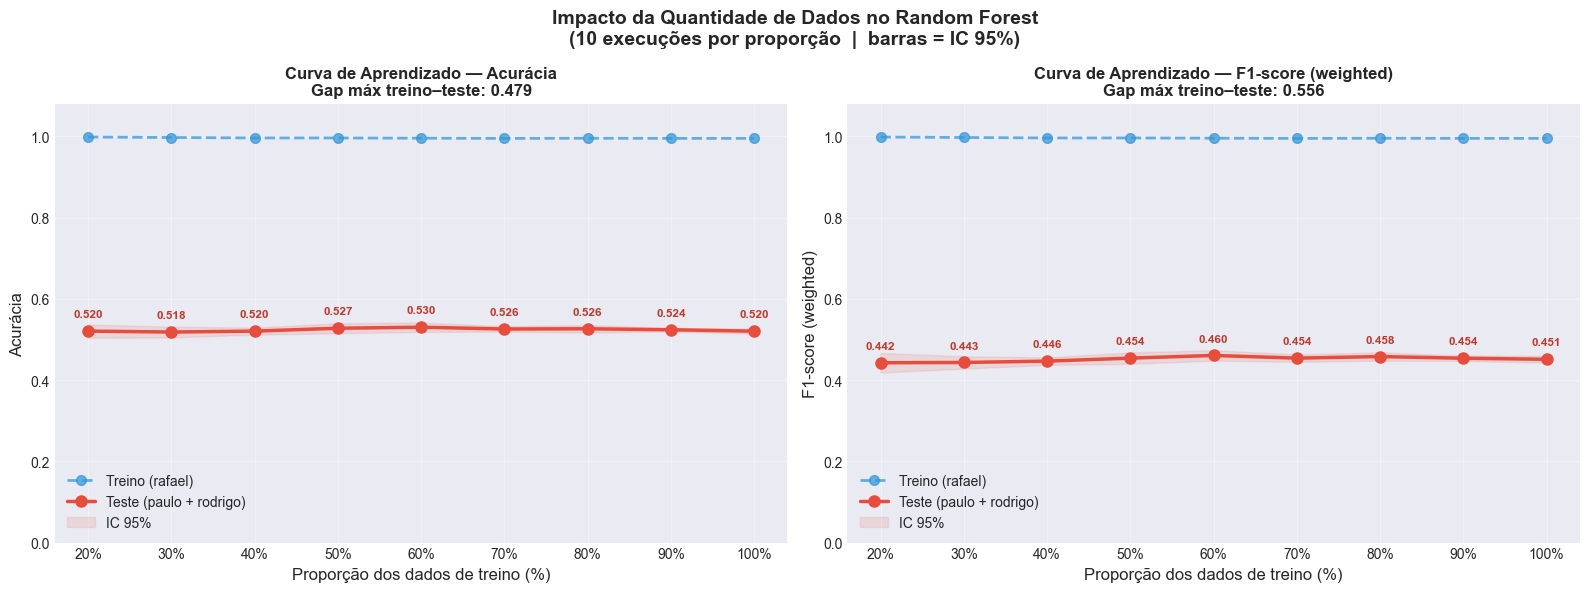

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pcts = agg['pct'].values

for ax, metric, label in [
    (axes[0], 'acc', 'Acurácia'),
    (axes[1], 'f1',  'F1-score (weighted)'),
]:
    mu_te  = agg[f'{metric}_test_mean'].values
    ci_te  = agg[f'{metric}_test_ci'].values
    mu_tr  = agg[f'{metric}_train_mean'].values

    # Treino
    ax.plot(pcts, mu_tr, 'o--', color='#3498db', linewidth=2, markersize=7,
            label='Treino (rafael)', alpha=0.75)

    # Teste
    ax.plot(pcts, mu_te, 'o-', color='#e74c3c', linewidth=2.5, markersize=8,
            label='Teste (paulo + rodrigo)')
    ax.fill_between(pcts, mu_te - ci_te, mu_te + ci_te,
                    color='#e74c3c', alpha=0.12, label='IC 95%')

    # Anotar valores no teste
    for x, y, ci in zip(pcts, mu_te, ci_te):
        ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    fontsize=8.5, fontweight='bold', color='#c0392b')

    ax.set_xlabel('Proporção dos dados de treino (%)', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'Curva de Aprendizado — {label}', fontsize=13, fontweight='bold')
    ax.set_xticks(pcts)
    ax.set_xticklabels([f'{p}%' for p in pcts])
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.35)

    # Destacar gap treino-teste
    gap_max = np.max(mu_tr - mu_te)
    ax.set_title(
        f'Curva de Aprendizado — {label}\nGap máx treino–teste: {gap_max:.3f}',
        fontsize=12, fontweight='bold'
    )

plt.suptitle(
    f'Impacto da Quantidade de Dados no Random Forest\n'
    f'({N_RUNS} execuções por proporção  |  barras = IC 95%)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(ML_MODELS_DIR / 'learning_curve_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. F1 por Classe × Proporção
Qual exercício se beneficia mais de mais dados?

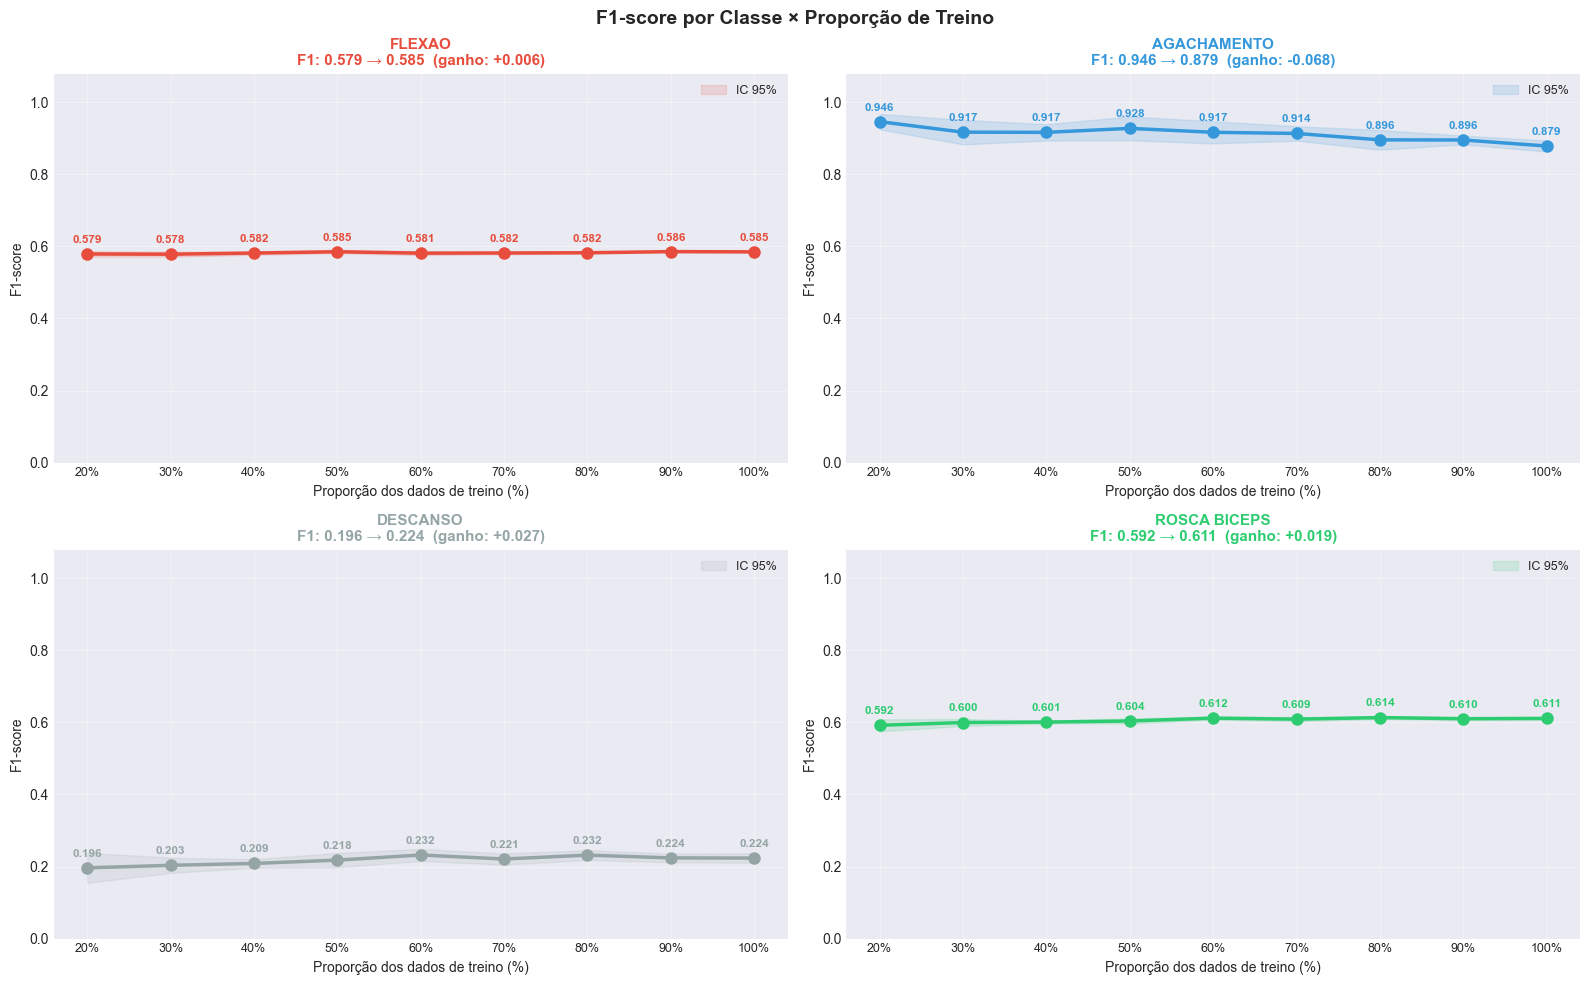

In [ ]:
EXERCISE_COLORS = {
    'flexao':       '#e74c3c',
    'agachamento':  '#3498db',
    'descanso':     '#95a5a6',
    'rosca_biceps': '#2ecc71',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (ex, lbl) in zip(axes, label_map.items()):
    mu = agg[f'f1_{ex}_mean'].values
    sd = agg[f'f1_{ex}_std'].values
    ci = 1.96 * sd / np.sqrt(N_RUNS)
    col = EXERCISE_COLORS[ex]

    ax.plot(pcts, mu, 'o-', color=col, linewidth=2.5, markersize=8)
    ax.fill_between(pcts, mu - ci, mu + ci, color=col, alpha=0.15, label='IC 95%')

    for x, y in zip(pcts, mu):
        ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 8),
                    textcoords='offset points', ha='center',
                    fontsize=8.5, fontweight='bold', color=col)

    # Ganho de 20% → 100%
    ganho = mu[-1] - mu[0]
    ax.set_title(
        f'{ex.upper().replace("_", " ")}\nF1: {mu[0]:.3f} → {mu[-1]:.3f}  (ganho: {ganho:+.3f})',
        fontsize=11, fontweight='bold', color=col
    )
    ax.set_xlabel('Proporção dos dados de treino (%)')
    ax.set_ylabel('F1-score')
    ax.set_xticks(pcts)
    ax.set_xticklabels([f'{p}%' for p in pcts], fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.35)

plt.suptitle('F1-score por Classe × Proporção de Treino',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Gap Treino–Teste (Overfitting)
Gap alto = overfitting. Queremos o gap diminuindo conforme mais dados são adicionados.

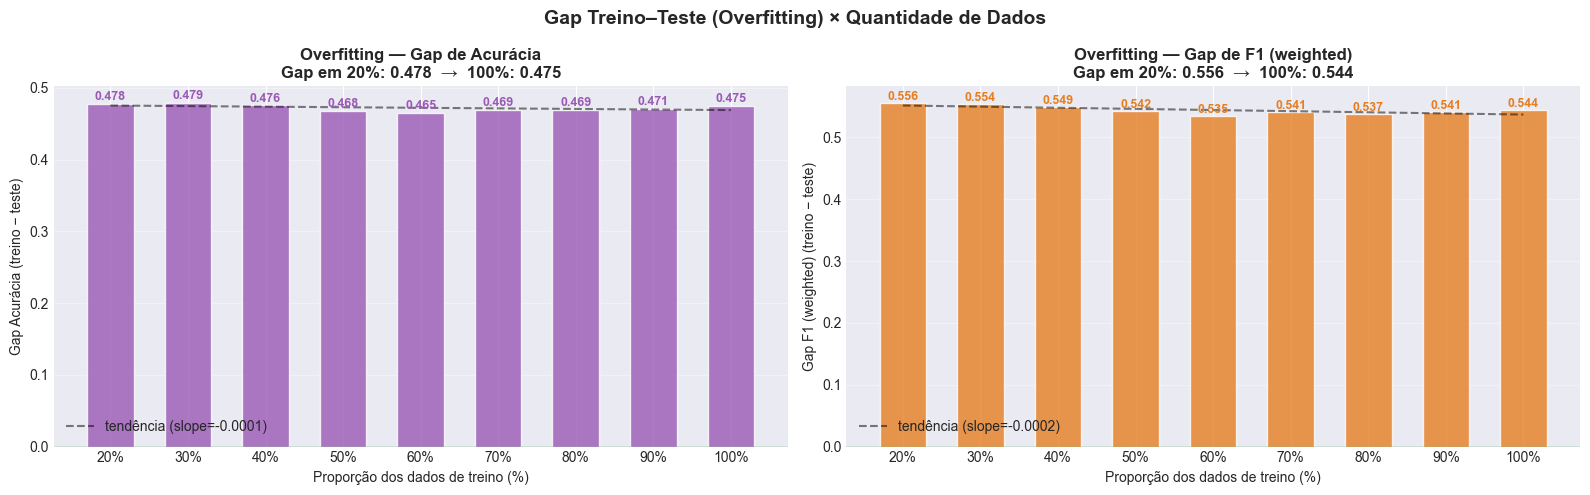

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Gap de acurácia
gap_acc = agg['acc_train_mean'].values - agg['acc_test_mean'].values
gap_f1  = agg['f1_train_mean'].values  - agg['f1_test_mean'].values

for ax, gap, metric_name, color in [
    (axes[0], gap_acc, 'Acurácia',          '#9b59b6'),
    (axes[1], gap_f1,  'F1 (weighted)',     '#e67e22'),
]:
    bars = ax.bar(pcts, gap, color=color, alpha=0.8, edgecolor='white', width=6)
    for bar, v in zip(bars, gap):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold', color=color)

    # Linha de tendência
    z = np.polyfit(pcts, gap, 1)
    p = np.poly1d(z)
    ax.plot(pcts, p(pcts), '--', color='black', alpha=0.5, linewidth=1.5,
            label=f'tendência (slope={z[0]:.4f})')

    ax.axhline(0, color='green', linewidth=1, alpha=0.6)
    ax.set_xlabel('Proporção dos dados de treino (%)')
    ax.set_ylabel(f'Gap {metric_name} (treino − teste)')
    ax.set_title(f'Overfitting — Gap de {metric_name}\n'
                 f'Gap em 20%: {gap[0]:.3f}  →  100%: {gap[-1]:.3f}',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(pcts)
    ax.set_xticklabels([f'{p}%' for p in pcts])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.35)

plt.suptitle('Gap Treino–Teste (Overfitting) × Quantidade de Dados',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Variabilidade entre Execuções
Boxplot de acurácia no teste por proporção — mostra estabilidade do treinamento.

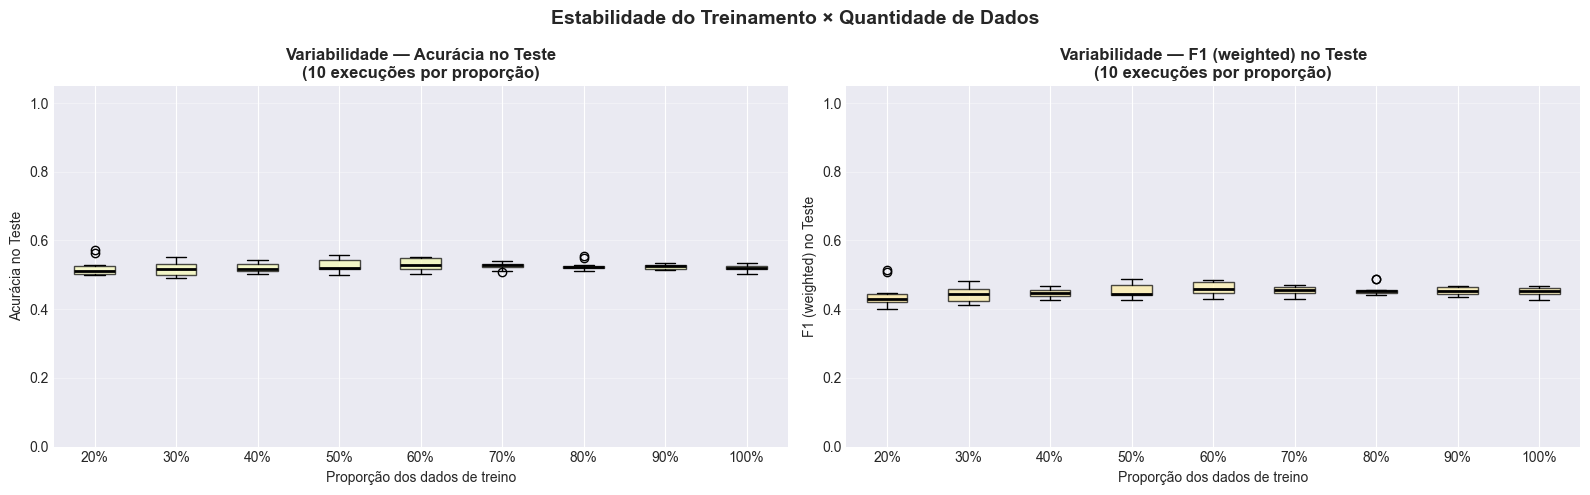

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col_y, title in [
    (axes[0], 'acc_test', 'Acurácia no Teste'),
    (axes[1], 'f1_test',  'F1 (weighted) no Teste'),
]:
    data_box = [df_runs[df_runs['pct'] == pct][col_y].values for pct in [p*100 for p in PROPORTIONS]]
    pct_labels = [f'{int(p*100)}%' for p in PROPORTIONS]

    bp = ax.boxplot(data_box, labels=pct_labels, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})

    cmap = plt.cm.RdYlGn
    for i, (patch, med) in enumerate(zip(bp['boxes'], [np.median(d) for d in data_box])):
        patch.set_facecolor(cmap(med))
        patch.set_alpha(0.7)

    ax.set_xlabel('Proporção dos dados de treino')
    ax.set_ylabel(title)
    ax.set_title(f'Variabilidade — {title}\n({N_RUNS} execuções por proporção)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.35)

plt.suptitle(f'Estabilidade do Treinamento × Quantidade de Dados',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Heatmap — F1 por Classe × Proporção

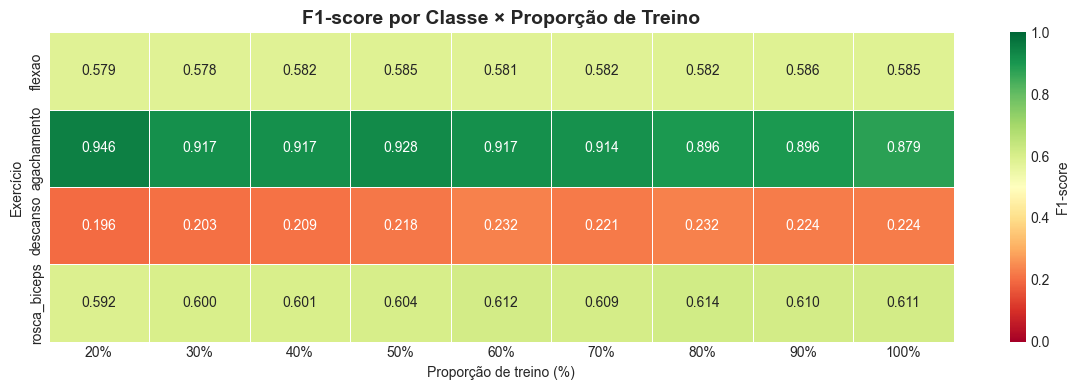

In [ ]:
hm_data = pd.DataFrame(
    {ex: agg[f'f1_{ex}_mean'].values for ex in label_map},
    index=[f'{p}%' for p in pcts]
).T

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    hm_data, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'F1-score'}
)
ax.set_title('F1-score por Classe × Proporção de Treino',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Proporção de treino (%)')
ax.set_ylabel('Exercício')
plt.tight_layout()
plt.show()

## 9. Resumo e Conclusões

In [ ]:
print('=' * 65)
print('  IMPACTO DA QUANTIDADE DE DADOS NO RANDOM FOREST')
print('  Split: treino=rafael  |  teste=paulo+rodrigo')
print('=' * 65)

row_20  = agg[agg['pct'] == 20].iloc[0]
row_100 = agg[agg['pct'] == 100].iloc[0]

print(f'\n📊 Acurácia no teste:')
print(f'   20% dos dados : {row_20.acc_test_mean:.4f} ± {row_20.acc_test_ci:.4f}')
print(f'  100% dos dados : {row_100.acc_test_mean:.4f} ± {row_100.acc_test_ci:.4f}')
print(f'  Ganho total    : {(row_100.acc_test_mean - row_20.acc_test_mean):+.4f}')

print(f'\n📊 F1 (weighted) no teste:')
print(f'   20% dos dados : {row_20.f1_test_mean:.4f} ± {row_20.f1_test_ci:.4f}')
print(f'  100% dos dados : {row_100.f1_test_mean:.4f} ± {row_100.f1_test_ci:.4f}')
print(f'  Ganho total    : {(row_100.f1_test_mean - row_20.f1_test_mean):+.4f}')

best_row = agg.loc[agg['acc_test_mean'].idxmax()]
print(f'\n🏆 Melhor proporção: {int(best_row.pct)}%  → acc={best_row.acc_test_mean:.4f}')

print(f'\n📊 Ganho por classe (F1 — de 20% para 100%):')
for ex in label_map:
    g = row_100[f'f1_{ex}_mean'] - row_20[f'f1_{ex}_mean']
    print(f'   {ex:15}: {row_20[f"f1_{ex}_mean"]:.3f} → {row_100[f"f1_{ex}_mean"]:.3f}  ({g:+.3f})')

print(f'\n📊 Gap treino–teste (acurácia):')
print(f'   20% : {row_20.acc_train_mean - row_20.acc_test_mean:.4f}')
print(f'  100% : {row_100.acc_train_mean - row_100.acc_test_mean:.4f}')
trend = np.polyfit([int(r.pct) for _, r in agg.iterrows()],
                   [r.acc_train_mean - r.acc_test_mean for _, r in agg.iterrows()], 1)[0]
direction = 'diminui' if trend < 0 else 'aumenta'
print(f'  Tendência: gap {direction} com mais dados (slope={trend:.5f})')

print(f'\n🔍 INTERPRETAÇÃO:')
print(f'   O gap treino (99%) vs teste (~52%) indica overfitting estrutural.')
print(f'   Causa principal: treino com rafael apenas → padrões específicos do sujeito.')
print(f'   Adicionar mais variantes de rafael não resolve o problema de generalização.')
print(f'   Solução: incluir mais sujeitos no treino (paulo ou rodrigo).')

  IMPACTO DA QUANTIDADE DE DADOS NO RANDOM FOREST
  Split: treino=rafael  |  teste=paulo+rodrigo

📊 Acurácia no teste:
   20% dos dados : 0.5204 ± 0.0162
  100% dos dados : 0.5202 ± 0.0062
  Ganho total    : -0.0002

📊 F1 (weighted) no teste:
   20% dos dados : 0.4425 ± 0.0241
  100% dos dados : 0.4510 ± 0.0084
  Ganho total    : +0.0085

🏆 Melhor proporção: 60%  → acc=0.5300

📊 Ganho por classe (F1 — de 20% para 100%):
   flexao         : 0.579 → 0.585  (+0.006)
   agachamento    : 0.946 → 0.879  (-0.068)
   descanso       : 0.196 → 0.224  (+0.027)
   rosca_biceps   : 0.592 → 0.611  (+0.019)

📊 Gap treino–teste (acurácia):
   20% : 0.4777
  100% : 0.4747
  Tendência: gap diminui com mais dados (slope=-0.00008)

🔍 INTERPRETAÇÃO:
   O gap treino (99%) vs teste (~52%) indica overfitting estrutural.
   Causa principal: treino com rafael apenas → padrões específicos do sujeito.
   Adicionar mais variantes de rafael não resolve o problema de generalização.
   Solução: incluir mais sujeitos 

## 10. Salvar Resultados

In [ ]:
out_dir = ML_MODELS_DIR / 'data_impact'
out_dir.mkdir(exist_ok=True, parents=True)

df_runs.to_csv(out_dir / 'all_runs.csv', index=False)
print('✓ all_runs.csv')

agg.to_csv(out_dir / 'aggregated.csv', index=False)
print('✓ aggregated.csv')

print(f'\n✅ Resultados salvos em: {out_dir}')

✓ all_runs.csv
✓ aggregated.csv

✅ Resultados salvos em: ml_models\data_impact
